# Temporal EDA Notebook (LI-Medium)

## In this notebook, we will analyze the effect of time of day and day of week on detecting laundering patterns.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- CONFIG ----
LI_PATH = "/home/d2molina/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/LI-Medium_Trans.csv"
CHUNKSIZE = 2_000_000
TS_FORMAT = "%Y/%m/%d %H:%M"
N_PERM = 2000
SEED = 0

print("Using:", LI_PATH)

Using: /home/d2molina/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/LI-Medium_Trans.csv


In [5]:
def stream_time_aggregates(csv_path, chunksize=2_000_000, ts_format="%Y/%m/%d %H:%M"):
    # Aggregation containers
    hour_total = np.zeros(24, dtype=np.int64)
    hour_pos   = np.zeros(24, dtype=np.int64)

    dow_total  = np.zeros(7, dtype=np.int64)  # Monday=0 ... Sunday=6
    dow_pos    = np.zeros(7, dtype=np.int64)

    hd_total   = np.zeros((7, 24), dtype=np.int64)  # dow x hour
    hd_pos     = np.zeros((7, 24), dtype=np.int64)

    total_rows = 0
    bad_ts = 0

    usecols = ["Timestamp", "Is Laundering"]

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        total_rows += len(chunk)

        # Normalize label (handles "0"/"1" strings)
        y = chunk["Is Laundering"].astype(str).astype(int).to_numpy(dtype=np.int8)

        # Parse timestamp
        if ts_format is None:
            ts = pd.to_datetime(chunk["Timestamp"], errors="coerce")
        else:
            ts = pd.to_datetime(chunk["Timestamp"], format=ts_format, errors="coerce")

        mask = ts.notna().to_numpy()
        if not mask.all():
            bad_ts += int((~mask).sum())

        ts = ts[mask]
        y  = y[mask]

        # Extract time features
        hour = ts.dt.hour.to_numpy(dtype=np.int16)
        dow  = ts.dt.dayofweek.to_numpy(dtype=np.int16)  # Mon=0..Sun=6

        # Aggregate: hour
        hour_total += np.bincount(hour, minlength=24)
        hour_pos   += np.bincount(hour, weights=y, minlength=24).astype(np.int64)

        # Aggregate: dow
        dow_total += np.bincount(dow, minlength=7)
        dow_pos   += np.bincount(dow, weights=y, minlength=7).astype(np.int64)

        # Aggregate: dow x hour
        idx = dow * 24 + hour
        flat_total = np.bincount(idx, minlength=7*24).reshape(7, 24)
        flat_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

        hd_total += flat_total
        hd_pos   += flat_pos

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": total_rows,
        "bad_ts": bad_ts
    }

agg = stream_time_aggregates(LI_PATH, chunksize=CHUNKSIZE, ts_format=TS_FORMAT)

print("Total rows processed:", agg["total_rows"])
print("Bad/unparsed timestamps:", agg["bad_ts"])
print("Overall positive rate:", agg["hour_pos"].sum() / max(agg["hour_total"].sum(), 1))

Total rows processed: 31251483
Bad/unparsed timestamps: 0
Overall positive rate: 0.0005132876414216887


In [6]:
hour_total = agg["hour_total"]
hour_pos   = agg["hour_pos"]
dow_total  = agg["dow_total"]
dow_pos    = agg["dow_pos"]
hd_total   = agg["hd_total"]
hd_pos     = agg["hd_pos"]

hour_rate = hour_pos / np.maximum(hour_total, 1)
dow_rate  = dow_pos  / np.maximum(dow_total, 1)
hd_rate   = hd_pos   / np.maximum(hd_total, 1)

# Summary tables
hour_df = pd.DataFrame({
    "hour": np.arange(24),
    "tx_count": hour_total,
    "laundering_count": hour_pos,
    "laundering_rate": hour_rate
})

dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_df = pd.DataFrame({
    "dow": np.arange(7),
    "day": dow_names,
    "tx_count": dow_total,
    "laundering_count": dow_pos,
    "laundering_rate": dow_rate
})

display(hour_df.head())
display(dow_df)

,hour,tx_count,laundering_count,laundering_rate
0,0,3295704,602,0.000183
1,1,1215108,624,0.000514
2,2,1215244,585,0.000481
3,3,1215445,593,0.000488
4,4,1217765,542,0.000445


,dow,day,tx_count,laundering_count,laundering_rate
0,0,Mon,3786206,2113,0.000558
1,1,Tue,3781813,2099,0.000555
2,2,Wed,3782114,2035,0.000538
3,3,Thu,8159001,2965,0.000363
4,4,Fri,8485414,3186,0.000375
5,5,Sat,1628953,1821,0.001118
6,6,Sun,1627982,1822,0.001119


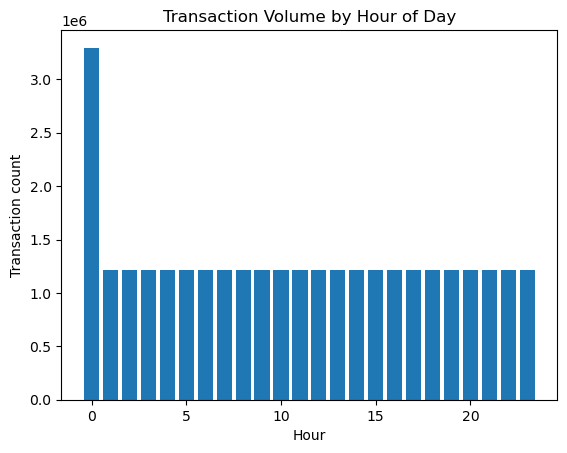

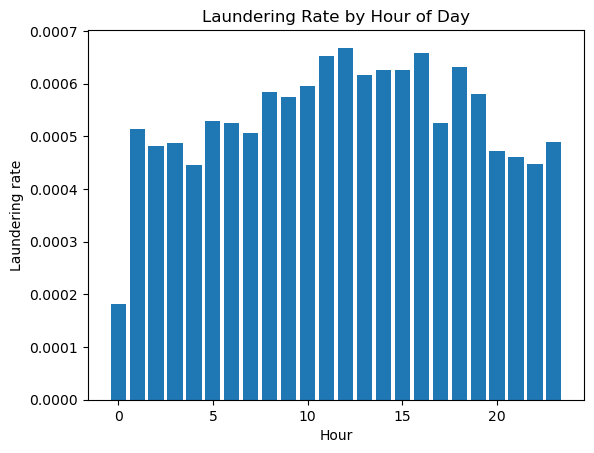

In [7]:
plt.figure()
plt.bar(hour_df["hour"], hour_df["tx_count"])
plt.title("Transaction Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transaction count")
plt.show()

plt.figure()
plt.bar(hour_df["hour"], hour_df["laundering_rate"])
plt.title("Laundering Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Laundering rate")
plt.show()

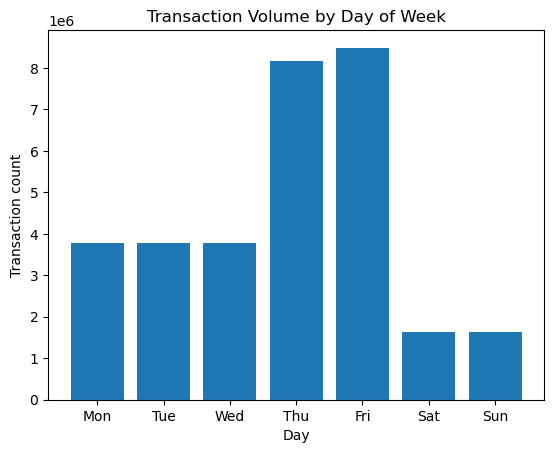

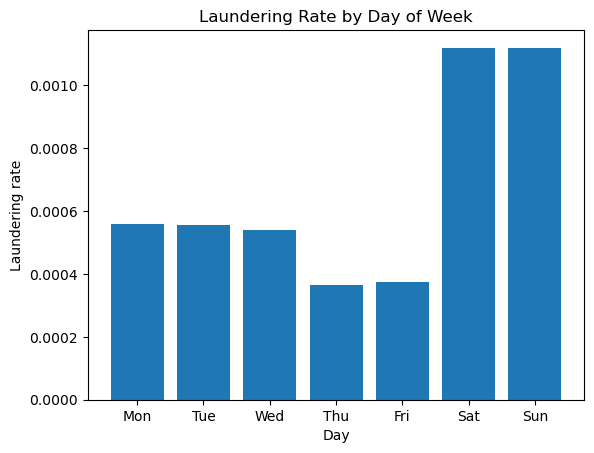

In [8]:
plt.figure()
plt.bar(dow_df["day"], dow_df["tx_count"])
plt.title("Transaction Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Transaction count")
plt.show()

plt.figure()
plt.bar(dow_df["day"], dow_df["laundering_rate"])
plt.title("Laundering Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Laundering rate")
plt.show()

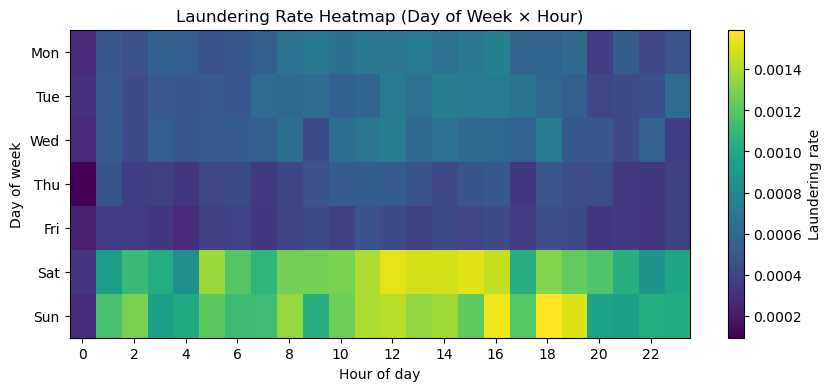

In [9]:
plt.figure(figsize=(10, 4))
plt.imshow(hd_rate, aspect="auto", interpolation="nearest")
plt.title("Laundering Rate Heatmap (Day of Week × Hour)")
plt.yticks(np.arange(7), dow_names)
plt.xticks(np.arange(0, 24, 2), np.arange(0, 24, 2))
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.colorbar(label="Laundering rate")
plt.show()

## This heatmap suggests that laundering rate is not time-uniform and shows weekly structure, with elevated weekend rates. Weekend time buckets show higher conditional laundering probability.

In [10]:
def chisq_stat(observed_pos, totals):
    """
    Pearson chi-square statistic comparing observed positive counts per bucket
    to expected counts under independence.
    """
    K = observed_pos.sum()
    N = totals.sum()
    p = totals / max(N, 1)

    expected = K * p
    # avoid division by 0 in empty buckets
    mask = expected > 0
    stat = np.sum((observed_pos[mask] - expected[mask])**2 / expected[mask])
    return float(stat)

obs_hour_stat = chisq_stat(hour_pos, hour_total)
obs_dow_stat  = chisq_stat(dow_pos, dow_total)

print("Observed chi-square stat (hour):", obs_hour_stat)
print("Observed chi-square stat (dow) :", obs_dow_stat)

Observed chi-square stat (hour): 1059.0340644691057
Observed chi-square stat (dow) : 3027.6923496359086


In [11]:
rng = np.random.default_rng(SEED)

def null_pvalue(observed_stat, observed_pos, totals, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)

    K = int(observed_pos.sum())
    N = int(totals.sum())
    p = totals / max(N, 1)

    sims = np.empty(n_perm, dtype=np.float64)
    for i in range(n_perm):
        sim_pos = rng.multinomial(K, p)
        sims[i] = chisq_stat(sim_pos, totals)

    pval = (np.sum(sims >= observed_stat) + 1) / (n_perm + 1)  # add-one smoothing
    return pval, sims

p_hour, sims_hour = null_pvalue(obs_hour_stat, hour_pos, hour_total, n_perm=N_PERM, seed=SEED)
p_dow,  sims_dow  = null_pvalue(obs_dow_stat,  dow_pos,  dow_total,  n_perm=N_PERM, seed=SEED+1)

print(f"Hour-of-day association p-value: {p_hour:.4g}")
print(f"Day-of-week association p-value: {p_dow:.4g}")

Hour-of-day association p-value: 0.0004998
Day-of-week association p-value: 0.0004998


## Both tests here hit the resolution floor. In other words, none of the 2000 null simulations produced a statistic as extreme as the observed statistic.

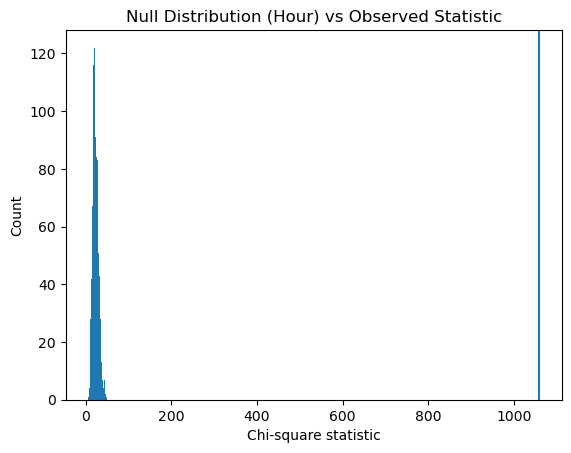

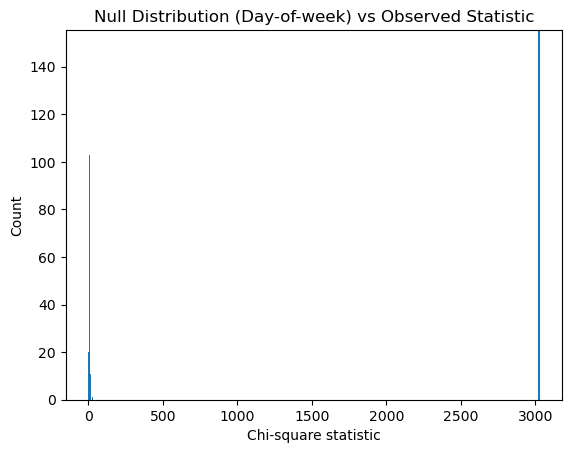

In [12]:
plt.figure()
plt.hist(sims_hour, bins=50)
plt.axvline(obs_hour_stat)
plt.title("Null Distribution (Hour) vs Observed Statistic")
plt.xlabel("Chi-square statistic")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(sims_dow, bins=50)
plt.axvline(obs_dow_stat)
plt.title("Null Distribution (Day-of-week) vs Observed Statistic")
plt.xlabel("Chi-square statistic")
plt.ylabel("Count")
plt.show()